# 🚀 Training State Space Models with `Linax`

Welcome to your first notebook on State Space Models (SSMs)! 🎓

**Our Goal**: Take you from zero to hero 🦸 in SSMs through this hands-on learning journey. By the end of these notebooks, you'll have a deep understanding of SSMs and how to train them effectively using `Linax`.

Let's dive in! 💪


This notebook demonstrates how to train an SSM (State Space Model) on the [MNIST SEQUENCE](https://edwin-de-jong.github.io/blog/mnist-sequence-data/) dataset using [`JAX`](https://github.com/google/jax), [`Equinox`](https://github.com/patrick-kidger/equinox) and **[`Linax`](https://github.com/tk-rusch/linoss)**.

In this notebook we will train a **LinOSS** [2] (Linear Oscillatory State-Space) model.

### About Linax

**Linax** is a library for state-space sequence modeling built on JAX and Equinox. It provides:

- 🚀 **Modern SSM architectures**: LRU, LinOSS and other state-of-the-art models
- ⚡ **JAX-native**: Full JIT compilation and automatic differentiation
- 🎯 **Clean API**: Built on Equinox for elegant, PyTorch-like model definitions

### Key Features:

- **Linax** - The SSM library (main focus!)
- **JAX** - For automatic differentiation and JIT compilation
- **Equinox** - For elegant neural network modeling

### What is LinOSS? 🧬

LinOSS (Linear Oscillatory State-Space) is a state-space sequence model based on forced harmonic oscillators. Inspired by cortical dynamics of biological neural networks, LinOSS models sequences using a system of forced linear second-order ODEs (ordinary differential equations). This oscillatory approach enables:

- **Stable long-range modeling**: Produces stable dynamics with only nonnegative diagonal state matrices
- **Efficient computation**: Uses fast associative parallel scans for training and inference
- **Universal approximation**: Can approximate any continuous causal operator mapping between time-series
- **Long-horizon forecasting**: Maintains accuracy over very long sequences (tested up to 50k timesteps)

### About the dataset ✍️

In this example, we use the **MNIST Sequence dataset**, where handwritten digits are represented as sequences of pen strokes. Each timestep contains (x, y) coordinates along with stroke/digit end markers, capturing the temporal dynamics of how the digit was drawn.

## Imports

We use:
- **Linax** - Our SSM library providing the core building blocks
- **JAX/Equinox** - Foundation libraries for the model definition and training loop
- **PyTorch** - For efficient data loading via DataLoader (converted to NumPy for JAX)
- **Optax** - For optimization algorithms (AdamW)
- **jaxtyping** - For type annotations with array shapes


In [1]:
import jax
import torch
from datasets import MNISTSeq

# from linax.models.linoss import LinossModel, LinossModelConfi

## Hyperparameters

We define our training configuration. These values have been chosen for quick experimentation and demonstration purposes:

- **Batch Size**: Small batches (10) for faster iteration during development
- **Learning Rate**: $3 \times 10^{-4}$ is a good default for AdamW
- **Steps**: 300 steps for quick training (increase for better performance)
- **Print Every**: Evaluate after every step to monitor progress closely


In [2]:
# Training configuration
BATCH_SIZE = 10  # Number of samples per batch
LEARNING_RATE = 3e-4  # AdamW learning rate
STEPS = 300  # Total training steps
PRINT_EVERY = 1  # Evaluation frequency
SEED = 5678  # Random seed for reproducibility

key = jax.random.PRNGKey(SEED)

## Data Loading 📊

We load the **MNIST Sequence dataset** where handwritten digits are represented as sequences of pen strokes.

### Dataset Details:
- **Sequences**: Each sample is 128 timesteps long
- **Features**: 4 features per timestep (dx, dy, stroke_end, digit_end)
- **Labels**: Digit class (0-9)

### Preprocessing:
The `MNISTSeq` dataset automatically:
1. Downloads the data from the official source
2. Pads/truncates sequences to fixed length (128)
3. Returns PyTorch tensors (which we convert to NumPy for JAX)

In [3]:
# Load MNIST Sequence dataset
train_dataset = MNISTSeq(
    root="./data_dir",
    train=True,
    download=True,
    timesteps=128,  # Each sequence has 128 timesteps
)

test_dataset = MNISTSeq(root="./data_dir", train=False, download=True)

# Create DataLoaders for efficient batching
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

testloader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Inspecting the Data

Let's verify our data shapes and examine a sample batch to ensure everything is loaded correctly.

**Expected shapes:**
- `x`: `(batch_size, 128, 4)` - sequences of pixels
- `y`: `(batch_size,)` - class labels (digits 0-9)

In [4]:
# Get a sample batch to verify shapes
dummy_x, dummy_y = next(iter(trainloader))
dummy_x = dummy_x.numpy()
dummy_y = dummy_y.numpy()
print(f"Input shape: {dummy_x.shape}")  # (batch_size, 128, 4)
print(f"Label shape: {dummy_y.shape}")  # (batch_size,)
print(f"Sample labels: {dummy_y}")  # Example digit labels

Input shape: (10, 128, 4)
Label shape: (10,)
Sample labels: [8 9 0 2 5 2 2 9 8 4]


### Visualizing MNIST Sequence

Let's visualize 4 sample images from the training set to see what our model will be learning from:

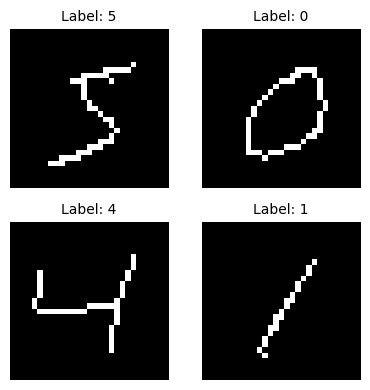

In [6]:
train_dataset.plot_samples(num_samples=4, figsize=(4, 4))

In [ ]:
###

## References

1. **Linax GitHub Repository**: https://github.com/camail-official/linax (⭐ Star the repo!)
2. **LinOSS Paper**: Rusch, T. K., & Rus, D. (2024). "Oscillatory State-Space Models". *arXiv preprint arXiv:2410.03943*. https://arxiv.org/abs/2410.03943
3. **Equinox Documentation**: https://docs.kidger.site/equinox/
4. **JAX Documentation**: https://jax.readthedocs.io/
5. **MNIST SEQUENCE Dataset**: https://edwin-de-jong.github.io/blog/mnist-sequence-data/